<h3 style = "color:green">INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Netflix is one of the world's leading streaming platforms, offering a vast collection of movies and TV shows across different genres, languages, and regions. This dataset, sourced from TMDb (The Movie Database), contains detailed information about Netflix content, including titles, genres, release dates, ratings, and descriptions. The dataset has been cleaned and structured to ensure consistency, making it suitable for exploratory data analysis (EDA). Through EDA, we can gain insights into Netflix's content library, identify patterns in content production, and understand trends in genres, ratings, and release years.
</div>

<h3 style = "color:green">OBJECTIVES

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Analyze the distribution of movies and TV shows available on Netflix.
<li>Explore content trends across release years.
<li>Identify the most common genres and content categories.
<li>Examine the distribution of ratings and audience classifications.
<li>Investigate patterns in content duration and popularity-related attributes.
<li>Discover relationships between different content features and uncover key insights about Netflix's catalog.
<li>Generate findings that can support content recommendation and business decision-making.

</div>

<h3 style = "color:green">Getting Ready With Data

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so


In [43]:
data = pl.read_csv('/home/kartika/Datasets/netflix_movies_detailed_up_to_2025.csv')
data = data.to_pandas()
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,None,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,None,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,None,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,None,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,None,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [44]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,None,Ha*ash,Chile,2025-02-24,2025,0.0,None,Music,es,None,4.931,0,0.0,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.0,None,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.0,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",None,2025-01-28,2025,1.0,None,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.0,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",None,2025-03-10,2025,0.0,None,None,en,A Dunces Burden,4.921,0,0.0,0,0
15999,1405742,Movie,Portal to Hell,Woody Bess,"Trey Holland, Keith David, Richard Kind, Micha...",United States of America,2025-02-22,2025,0.0,None,"Comedy, Horror",en,After a debt-collector finds a portal to hell ...,4.921,0,0.0,0,0


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      object 
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(3), int64(5), o

In [46]:
data.isnull().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

In [47]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There are some missing values(blank values) in director, cast, country, genres and description fields which will be handled during their respective analysis. No duplicate values are present.

In [48]:
data.drop(columns = ['show_id', 'type', 'description', 'title', 'cast', 'duration'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped unnecessary columns.

<div>

<h3 style = "color:green">Univariate Analysis

<h4 style = "color:green">Top Countries

In [8]:
data.country.isnull().sum()

np.int64(466)

In [9]:
data['country'] = data['country'].fillna('Unknown')

In [10]:
data.country.value_counts()

country
United States of America                                        5421
Japan                                                            845
South Korea                                                      789
France                                                           612
United Kingdom                                                   581
                                                                ... 
Argentina, Colombia, Venezuela                                     1
Luxembourg, Belgium, France                                        1
China, France, Hong Kong, Taiwan                                   1
South Korea, Spain, United Kingdom, United States of America       1
Belgium, Finland, France, Mexico, Netherlands                      1
Name: count, Length: 1464, dtype: int64

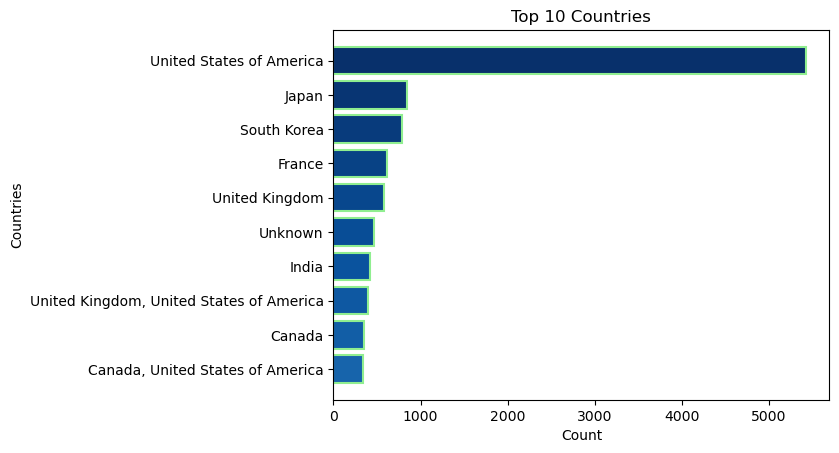

In [11]:
plt.barh(
        width = data['country'].value_counts().head(10).values,
        y= data['country'].value_counts().head(10).index,
        color = plt.cm.Blues(np.linspace(1, 0.8, 10)),
        linewidth = 1.5,
        edgecolor = 'lightgreen',

)

plt.title('Top 10 Countries')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.ylabel('Countries')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">USA has most movies in the dataset, follwed by China and Japan. Significant number of values are missing as well.

<div>

<h4 style = "color:green">Top Languages

In [12]:
data['language'].value_counts()

language
en    9534
fr    1054
ja     904
ko     876
es     731
      ... 
ur       1
ht       1
hy       1
sl       1
bg       1
Name: count, Length: 74, dtype: int64

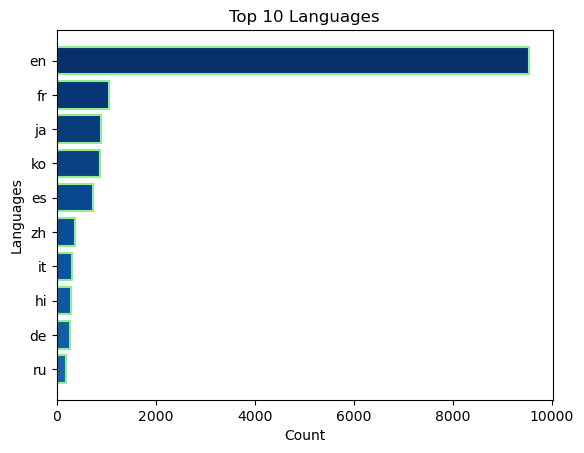

In [13]:
plt.barh(
        width = data['language'].value_counts().head(10).values,
        y= data['language'].value_counts().head(10).index,
        color = plt.cm.Blues(np.linspace(1, 0.8, 10)),
        linewidth = 1.5,
        edgecolor = 'lightgreen',

)

plt.title('Top 10 Languages')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.ylabel('Languages')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The dataset is heavily dominated by English movies, followed by Chinese movies by great margin.

<div>

<h4 style = "color:green">Top Directors

In [14]:
data['director'].isnull().sum()

np.int64(132)

In [15]:
data['director'] = data['director'].fillna('Unknown')

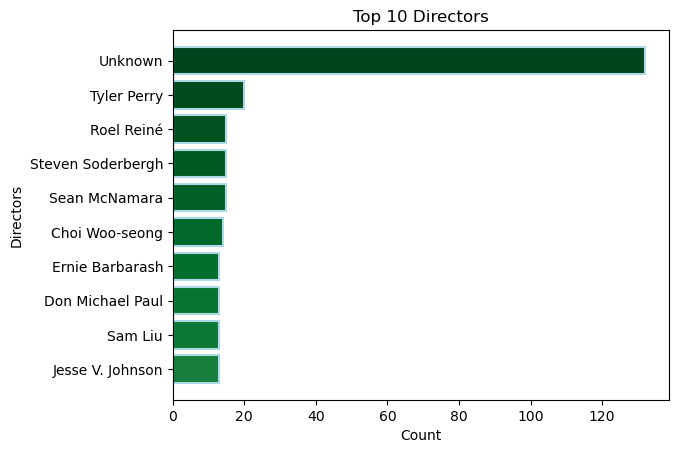

In [16]:
plt.barh(
        width = data['director'].value_counts().head(10).values,
        y= data['director'].value_counts().head(10).index,
        color = plt.cm.Greens(np.linspace(1, 0.8, 10)),
        linewidth = 1.5,
        edgecolor = 'lightblue',

)

plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.ylabel('Directors')
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">More than 50% of the records in director field is missing. In the present records, top director by number of movies are Don Michael Perez and Gil Tejada Jr. having 16 movies each.

<div>

<h4 style = "color:green">Rating Distribution

In [17]:
data['rating'].describe()

count    16000.000000
mean         5.956368
std          1.754741
min          0.000000
25%          5.600000
50%          6.300000
75%          6.923000
max         10.000000
Name: rating, dtype: float64

In [18]:
data['rating'].skew()

np.float64(-2.116594502398236)

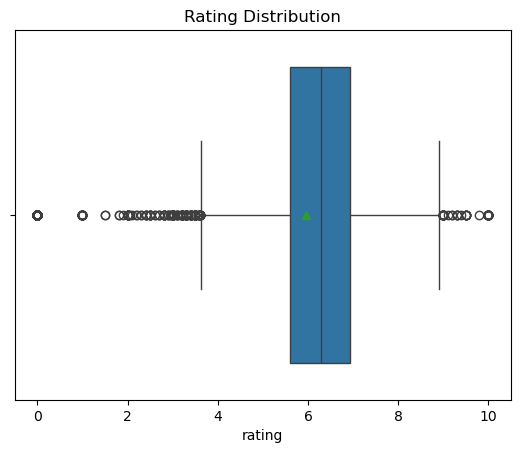

In [19]:
sns.boxplot(
    data = data,
    x = 'rating',
    showmeans = True
)

plt.title('Rating Distribution')
plt.show()

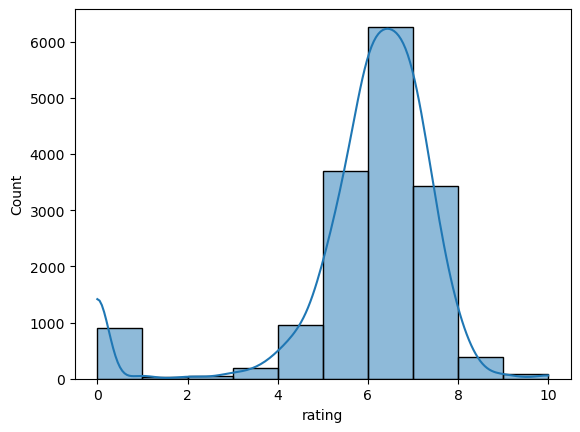

In [20]:
sns.histplot(
    data = data,
    x = 'rating',
    bins = 10,
    kde = True
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The distribution is moderately negatively skewed, indicating most of the movies have high rating and very few movies have unusual low rating.

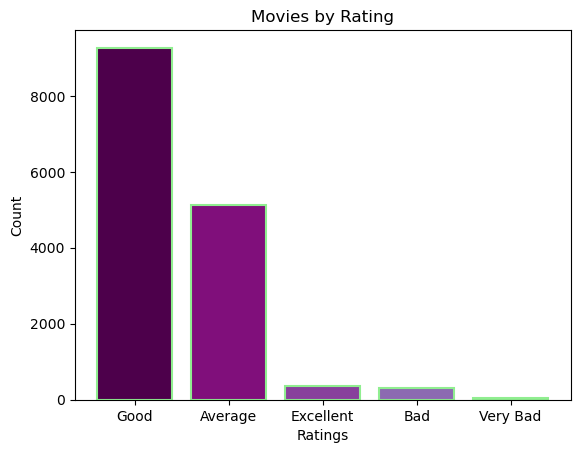

In [21]:
data['rating_category'] = pd.cut(data['rating'],
                                 bins = [0, 2, 4, 6, 8, 10],
                                 labels = ['Very Bad', 'Bad', 'Average', 'Good', 'Excellent'])

plt.bar(
    x = data['rating_category'].value_counts().index,
    height = data['rating_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Movies by Rating')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the movies have rating above average, very few have bad rating.

<div>

<h4 style = "color:green">Genres

In [22]:
data = data.assign(
    genres=data['genres'].str.split(",")).explode('genres')


In [23]:
data['genres'].isnull().sum()

np.int64(107)

In [24]:
data.fillna({'genres': 'Unknown'}, inplace = True)

In [25]:
data['genres'].value_counts().head(10)

genres
Drama         3634
 Drama        3276
 Thriller     2808
Comedy        2352
 Comedy       2181
Action        1883
 Romance      1657
Horror        1520
 Adventure    1387
 Action       1356
Name: count, dtype: int64

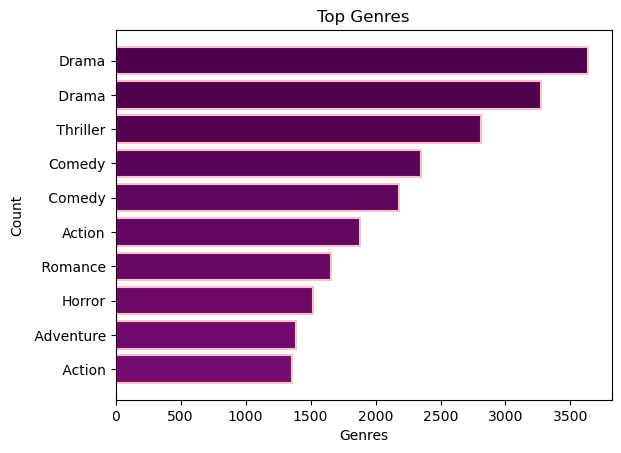

In [26]:
plt.barh(
     y = data['genres'].value_counts().head(10).index,
     width = data['genres'].value_counts().head(10).values,
     color = plt.cm.BuPu(np.linspace(1, 0.9, 10)),
     linewidth = 1.5,
     edgecolor = 'pink'
)

plt.title('Top Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Drama genre dominates the dataset by high margin. Comedy and Animation are moderately represented.

<div>

<h4 style = "color:green">Budget Distribution

In [49]:
data['budget'] = data['budget'].replace(0, np.nan)
data['budget'].isnull().sum()

np.int64(11153)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The column has a lot of missing values, which were represented as 0,so replaced with np.nan.

In [50]:
data['budget'].describe()

count    4.847000e+03
mean     2.893928e+07
std      4.708018e+07
min      1.000000e+00
25%      3.898000e+06
50%      1.050000e+07
75%      3.000000e+07
max      4.600000e+08
Name: budget, dtype: float64

In [51]:
data['budget'].skew()

np.float64(3.141050622409487)

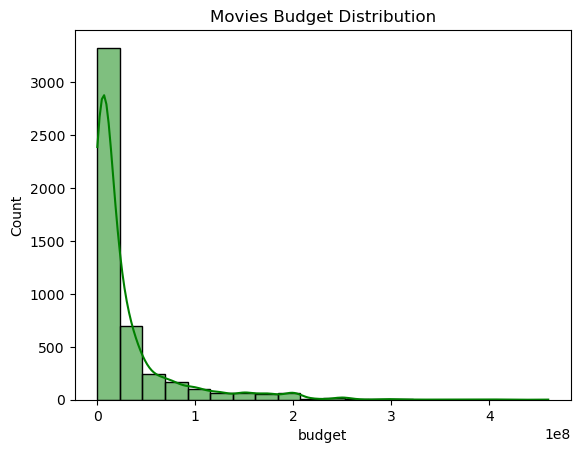

In [52]:
sns.histplot(
    data = data.loc[data['budget'].notna()],
    x = 'budget',
    bins = 20,
    color = 'green',
    kde = True
)

plt.title('Movies Budget Distribution')
plt.show()



<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The budget distribution is highly right-skewed, indicating most of the movies have low to medium budget (around mean), while few movies have very high budget.

<div>

<h4 style = "color:green">Revenue Distribution

In [53]:
data['revenue'] = data['revenue'].replace(0, np.nan)
data['revenue'].isnull().sum()

np.int64(10355)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The column has a lot of missing values which were represented with 0, so replaced with np.nan.

In [54]:
data['revenue'].describe()

count    5.645000e+03
mean     6.933733e+07
std      1.795958e+08
min      2.000000e+00
25%      1.100000e+06
50%      8.555008e+06
75%      4.915834e+07
max      2.799439e+09
Name: revenue, dtype: float64

In [55]:
data['revenue'].skew()

np.float64(5.429272906237106)

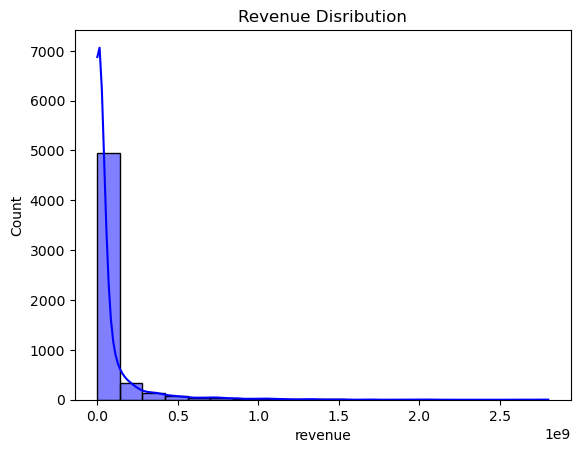

In [57]:
sns.histplot(
    data = data.loc[data['revenue'].notna()],
    x = 'revenue',
    bins = 20,
    color = 'blue',
    kde = True

)

plt.title('Revenue Disribution')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The revenue distribution is extremely right-skewed. Most of the movies have revenue low and below around mean, while few movies have exceptionally high revenue.

<div>

<h4 style = "color:green">Number of Movies Based on Year

In [58]:
data['release_year'].value_counts()

release_year
2010    1000
2011    1000
2012    1000
2013    1000
2014    1000
2015    1000
2016    1000
2017    1000
2018    1000
2019    1000
2020    1000
2021    1000
2022    1000
2023    1000
2024    1000
2025    1000
Name: count, dtype: int64

<div>

<div>

<h3 style = "color:green">Bivariate Analysis